# Le02 - Teorema da amostragem

Neste notebook trabalharemos na ''demostração'' (empírica) do Teorema da Amostragem, também conhecido como Teorema de Nyqvist–Shannon.

Também reforçaremos a ideia de **frequência de amostragem**, conceito CHAVE em sinais.

**Desafio:** Corrija a simulação pra que funcione!

## Primeiro passo!
Comece simulando um ''trem de *sincs*''.
Perceba como ele vai trabalhar no sinal de entrada!

<img src="./figures/sinc.png" alt="" width="500"/>

No final, responda: Qual o tamanho de ''t'' e de ''sinc''?

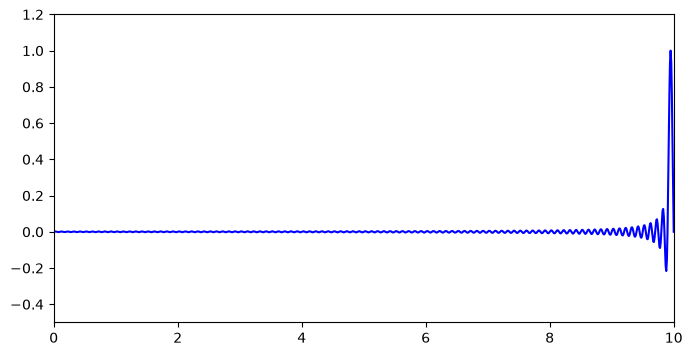

In [2]:
# Resposta 1
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

ti = 1e-12 # tempo inicial (liberando a singularidade para x=0 em sinc(x) / x)
tf = 10  # tempo final
Na = 1000 # Numero de amostras do sinal analogico
t = np.linspace(ti, tf, Na) # vetor de tempo (analogico)

fs = 20 # frequencia de amostragem
Ts = 1. / fs # tempo de amostragem

# Vetor de amostras discreto n: de 0 até tf*fs
n = np.arange(0, int((tf-ti)/Ts) + 1)

# Plot interativo
fig, ax = plt.subplots(figsize=(8,4))

for nn in n:
    # Trem de sincs: np.sinc no numpy e sin(pi*x)/(pi*x), logo passamos fs*(t - nn*Ts)
    sinc = np.sinc(fs * (t - nn * Ts))

    ax.cla()
    ax.set_xlim(ti, tf)
    ax.set_ylim(-0.5, 1.2)
    ax.plot(t, sinc, "b")
    display.display(fig)
    display.clear_output(wait = True)
plt.show()


In [1]:
# Resposta Desafio 2: Frequencia minima (Nyquist)
# Pelo teorema de Nyquist-Shannon, a frequencia de amostragem minima (fs) deve ser estritamente MAIOR que o dobro da frequencia maxima do sinal.
# fs > 2 * f_max

f_max = 2.0 # Nosso sinal de teste tem 2Hz
fs_min = 2 * f_max

print(f"Frequencia do sinal simulado: {f_max} Hz")
print(f"Frequencia de amostragem minima teorica (Nyquist): > {fs_min} Hz")
print("Se fs = 4 Hz cravado, as amostras caem exatamente nos zeros do seno, anulando a reconstrucao. Logo, fs deve ser no minimo 4.01 Hz para senoides.")


Frequencia do sinal simulado: 2.0 Hz
Frequencia de amostragem minima teorica (Nyquist): > 4.0 Hz
Se fs = 4 Hz cravado, as amostras caem exatamente nos zeros do seno, anulando a reconstrucao. Logo, fs deve ser no minimo 4.01 Hz para senoides.


## Desafio 1: Tempo de simular!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

import sys
sys.path.append('../../')
from lib.myPlotLib import *

ModuleNotFoundError: No module named 'lib'

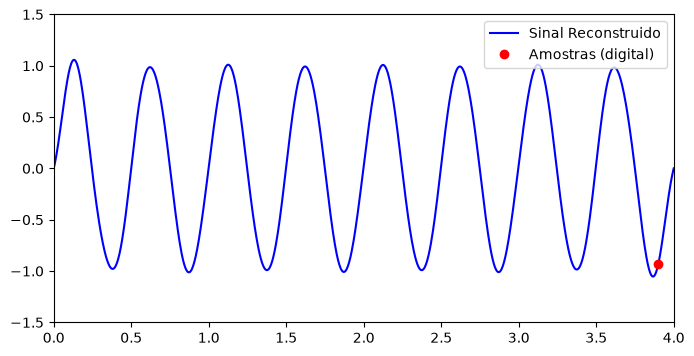

In [4]:
# Demostracao do Teorema da amostragem
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Sinal analogico simulado
ti = 0 # tempo inicial
tf = 4  # tempo final
Na = 1000 # Numero de amostras do sinal analogico
fa = Na / (tf - ti) # frequencia (de amostragem) do sinal analogico
T  = 1. / fa # tempo (de amostragem) do sinal analogico

t = np.linspace(ti, tf, Na) # vetor de tempo (analogico)

f = 2.0 # frequencia do sinal (2 Hz)
y = np.sin(2 * np.pi * f * t) # Sinal analogico original (onda senoidal)

# Sinal digital (amostrado a partir do original)
fs = 5 * f  # frequencia de amostragem (10 Hz > 2*2Hz, Nyquist satisfeito!)
Ts = 1. / fs # tempo de amostragem

Nd = int(fa // fs)
yn = y[::Nd]
n = np.arange(len(yn))

# Plot interativo da reconstrucao
fig, ax = plt.subplots(figsize=(8,4))

x = np.zeros(len(t))
for nn in n:
    # Reconstrucao interpolando as amostras com funcoes sinc
    x = x + yn[nn] * np.sinc(fs * (t - nn * Ts))
        
    ax.cla()
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(-1.5, 1.5)
    ax.plot(t, x, "b", label="Sinal Reconstruido")
    ax.plot(nn*Ts, yn[nn], "ro", label="Amostras (digital)")
    ax.legend(loc="upper right")
    display.display(fig)
    display.clear_output(wait = True)
plt.show()


Compare o resultado da reconstrução com o sinal original em gráficos

<img src="./figures/original-signal.png" alt="" width="500"/>

<img src="./figures/reconstructed-signal.png" alt="" width="500"/>

<img src="./figures/reconstructed-02.png" alt="" width="500"/>

In [ ]:
# Comparativo visual final: Original vs Reconstrucao
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(t, y, "g")
ax[0].set_title("Sinal Analogico Original (2 Hz)")
ax[1].plot(t, x, "b")
ax[1].set_title(f"Sinal Reconstruido a partir de fs = {fs} Hz")
ax[2].stem(n * Ts, yn, basefmt=" ")
ax[2].set_title("Amostras (Sinal Discreto)")
plt.tight_layout()
plt.show()


## Desafio 2:
Encontre empiricamente a minima **frequencia de amostragem** $fs$ para o sinal que você usou no exemplo anterior

In [ ]:
# Resposta Desafio 2: Frequencia minima (Nyquist)
# Pelo teorema de Nyquist-Shannon, a frequencia de amostragem minima (fs) deve ser estritamente MAIOR que o dobro da frequencia maxima do sinal.
# fs > 2 * f_max

f_max = 2.0 # Nosso sinal de teste tem 2Hz
fs_min = 2 * f_max

print(f"Frequencia do sinal simulado: {f_max} Hz")
print(f"Frequencia de amostragem minima teorica (Nyquist): > {fs_min} Hz")
print("Se fs = 4 Hz cravado, as amostras caem exatamente nos zeros do seno, anulando a reconstrucao. Logo, fs deve ser no minimo 4.01 Hz para senoides.")


## Desafio 3:

1. Importe um sinal de áudio da sua preferência
2. Analise o sinal e encontre a frequencia de amostragem $fs$ minima que satisfaça o Teorema da Amostragem de Shannon-Nyqvist
3. Reconstrua o seu sinal com frequencias de amostragens maiores e menores do que a original. Reporte o que acontece em cada caso?

In [ ]:
import os
import sys
sys.path.append("../../") # Para alcancar a pasta lib
from lib.myAudioProcessingLib import audioread
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# 1. Importar o sinal de audio
SOUND_FILE = os.path.join("../../sounds", "BS_paranoid.wav") # Ajuste do path relativo!
try:
    x_audio, fs_audio = audioread(SOUND_FILE)
    print(f"Audio Original: Shape {x_audio.shape}, Frequencia de Amostragem (fs) = {fs_audio} Hz")
    
    # 2 e 3. Teorema de Nyqvist e Subamostragem (Undersampling)
    # Para um audio de fs=44100Hz, a frequencia maxima suportada sem aliasing e ~22050Hz.
    # Se subamostrarmos (pularmos amostras), vamos induzir Aliasing intencional.
    
    fator_sub = 8 # Pegamos 1 a cada 8 amostras
    x_sub = x_audio[::fator_sub]
    fs_sub = fs_audio // fator_sub
    print(f"Audio Subamostrado (Aliasing!): Shape {x_sub.shape}, Frequencia de Amostragem (fs) = {fs_sub} Hz")
    
    # Descomente abaixo em seu Jupyter para OUVIR a diferenca brutal (perda de agudos e aliasing metalico):
    # display(Audio(data=x_audio[:, 0] if x_audio.ndim > 1 else x_audio, rate=fs_audio))
    # display(Audio(data=x_sub[:, 0] if x_sub.ndim > 1 else x_sub, rate=fs_sub))
except Exception as e:
    print("Nao foi possivel carregar o audio. Erro:", e)
